In [78]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer


# Download resources
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/harini/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/harini/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [77]:
df = pd.read_excel("/Users/harini/Desktop/Student Fashion Preferences and Spending Analysis (Responses).xlsx")

df.head()

,Timestamp,Gender,What is your current level of study?,Which type of clothing do you prefer the most?,What do you usually prefer to wear for college use?,Does your college have a uniform policy?,How often you buy clothes ?,Which shopping method do you prefer?,what do you prefer in this for shopping ?,What price range do you prefer per clothing item?,What is your average spending ?\n(per year)\n,Are discounts and offers important while purchasing clothes?,How confident are you while selecting clothes without assistance?,What is the main reason for regret ?,"Do you take opinions before purchasing, if yes whose opinion?",What makes you trust a fashion brand or platform?,Which factor would make you buy a brand more frequently?,"Is there anything you would like to share about your fashion choices, shopping experience, or challenges you face while buying clothes?"
0,2025-12-19 07:40:29,Female,MBA,Casual wear,Mixed,Yes,3-6 Months,Offline shopping,"Better prices, Try before buying",₹500 – ₹1000,8000.0,Yes,Very confident,Price not worth it,No one,Reviews,Better prices,NaN
1,2025-12-19 08:10:51,Female,B.Tech / B.E,Casual wear,Casual wear,No,2-3 Weeks,Both,"Better prices, More variety, Try before buying",Above ₹2000,15000.0,Sometimes,Very confident,Different from images,Reviews & ratings,Quality assurance,Better prices,No
2,2025-12-19 08:58:58,Male,B.Tech / B.E,Casual wear,Mixed,Yes,Once a Year,Online shopping,"More variety, Convenience",₹500 – ₹1000,5000.0,Yes,Very confident,No regret,Family,Brand reputation,suggestions,no
3,2025-12-19 09:22:03,Male,Diploma,Formal wear,Jeans & T-shirts,No,Once a Year,Both,"More variety, Convenience",₹500 – ₹1000,20000.0,Yes,Somewhat confident,Quality issues,Family,Quality assurance,Better quality,NaN
4,2025-12-19 09:27:03,Female,MBBS/BDS,Casual wear,Formals,Yes,1-2 Months,Both,"Better prices, Try before buying",₹500 – ₹1000,8000.0,Yes,Very confident,Poor fit,Friends,Reviews,Better quality,NaN


In [3]:
df.shape
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5006 entries, 0 to 5005
Data columns (total 18 columns):
 #   Column                                                                                                                                   Non-Null Count  Dtype         
---  ------                                                                                                                                   --------------  -----         
 0   Timestamp                                                                                                                                5006 non-null   datetime64[ns]
 1   Gender                                                                                                                                   5006 non-null   object        
 2   What is your current level of study?                                                                                                     5006 non-null   object        
 3   Which type of clothing 

Index(['Timestamp', 'Gender', 'What is your current level of study?',
       'Which type of clothing do you prefer the most?',
       'What do you usually  prefer  to wear for college use?',
       'Does your college have a uniform policy?',
       'How often you buy clothes ?', 'Which shopping method do you prefer?',
       'what do you prefer in this for shopping ?',
       'What price range do you prefer per clothing item?',
       'What is your average spending ?\n(per year)\n',
       'Are discounts and offers important while purchasing clothes?',
       'How confident are you while selecting clothes without assistance?',
       'What is the main reason for regret ?',
       'Do you take opinions  before purchasing, if yes whose opinion?',
       'What makes you trust a fashion brand or platform?',
       'Which factor would make you buy a brand more frequently?',
       'Is there anything you would like to share about your fashion choices, shopping experience, or challenges you f

In [61]:
target = df["Which shopping method do you prefer?"]

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    target,
    test_size=0.2,
    random_state=42
)

In [63]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [64]:
y_pred = model.predict(X_test)

In [65]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.504950495049505


In [66]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[51  0  0]
 [28  0  0]
 [22  0  0]]


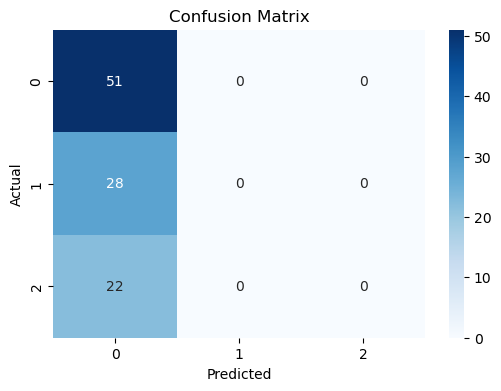

In [67]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [68]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

print(report)

                  precision    recall  f1-score   support

            both       0.50      1.00      0.67        51
offline shopping       0.00      0.00      0.00        28
 online shopping       0.00      0.00      0.00        22

        accuracy                           0.50       101
       macro avg       0.17      0.33      0.22       101
    weighted avg       0.25      0.50      0.34       101



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [69]:
feature_names = tfidf.get_feature_names_out()

coefs = model.feature_log_prob_

top_words = feature_names[:20]

print(top_words)

['also' 'also look' 'better' 'better quality' 'challenge' 'challenge fit'
 'choose' 'choose unique' 'coloursfabrics' 'coloursfabrics face' 'comfort'
 'comfort better' 'comfortable' 'comfortable make' 'confident' 'dont'
 'dont rush' 'face' 'face challenge' 'fake']


In [74]:

pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


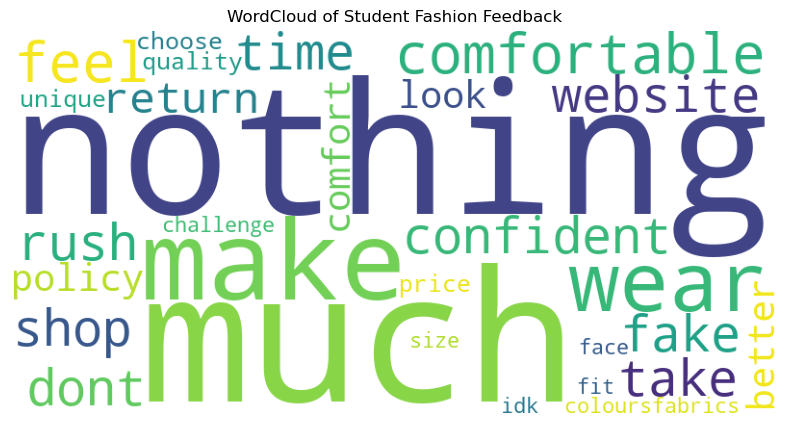

In [71]:
from wordcloud import WordCloud

text = " ".join(df["clean_feedback"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud of Student Fashion Feedback")
plt.show()

In [4]:
df.columns = df.columns.str.replace("\n"," ")
df.columns = df.columns.str.strip()

In [5]:
df.drop(columns=["Timestamp"], inplace=True)

In [6]:
df.isnull().sum()

Gender                                                                                                                                        0
What is your current level of study?                                                                                                          0
Which type of clothing do you prefer the most?                                                                                                0
What do you usually  prefer  to wear for college use?                                                                                         0
Does your college have a uniform policy?                                                                                                      1
How often you buy clothes ?                                                                                                                   0
Which shopping method do you prefer?                                                                                                    

In [7]:
df["Is there anything you would like to share about your fashion choices, shopping experience, or challenges you face while buying clothes?"] = df["Is there anything you would like to share about your fashion choices, shopping experience, or challenges you face while buying clothes?"].fillna("")

In [8]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

In [22]:
def convert_spending(x):

    x = str(x)

    if "below" in x:
        return 2500

    elif "5000-10000" in x:
        return 7500

    elif "10000-15000" in x:
        return 12500

    elif "15000-20000" in x:
        return 17500

    elif "20000" in x:
        return 22000

    else:
        return None


df["average_spending"] = df["What is your average spending ? (per year)"].apply(convert_spending)

In [23]:
df.describe()

,What is your average spending ? (per year),average_spending
count,5.006000e+03,504.0
mean,2.643747e+05,22000.0
std,1.744872e+07,0.0
min,1.000000e-09,22000.0
25%,5.000000e+03,22000.0
50%,1.200000e+04,22000.0
75%,2.500000e+04,22000.0
max,1.234568e+09,22000.0


In [11]:
df["average_spending"].describe()

count    5.006000e+03
mean     2.643747e+05
std      1.744872e+07
min      1.000000e-09
25%      5.000000e+03
50%      1.200000e+04
75%      2.500000e+04
max      1.234568e+09
Name: average_spending, dtype: float64

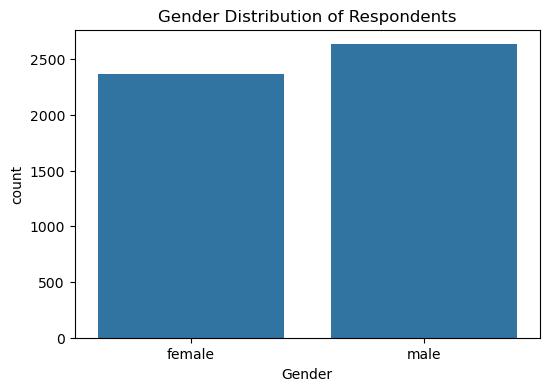

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution of Respondents")
plt.show()

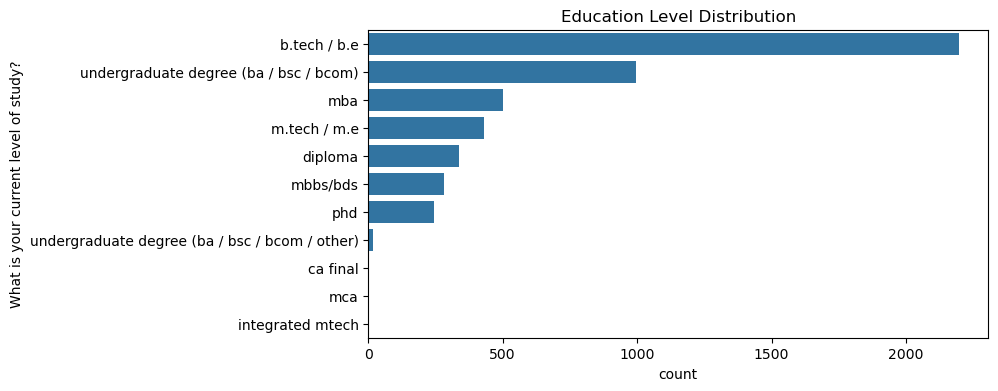

In [13]:
plt.figure(figsize=(8,4))
sns.countplot(
    y="What is your current level of study?",
    data=df,
    order=df["What is your current level of study?"].value_counts().index
)
plt.title("Education Level Distribution")
plt.show()

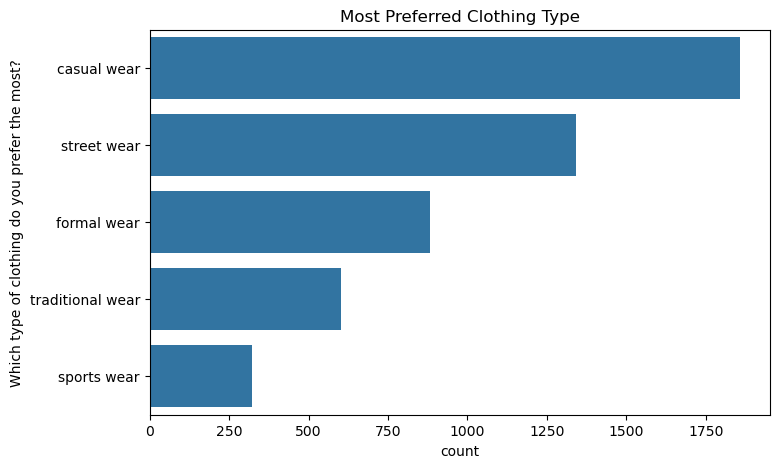

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(
    y="Which type of clothing do you prefer the most?",
    data=df,
    order=df["Which type of clothing do you prefer the most?"].value_counts().index
)
plt.title("Most Preferred Clothing Type")
plt.show()

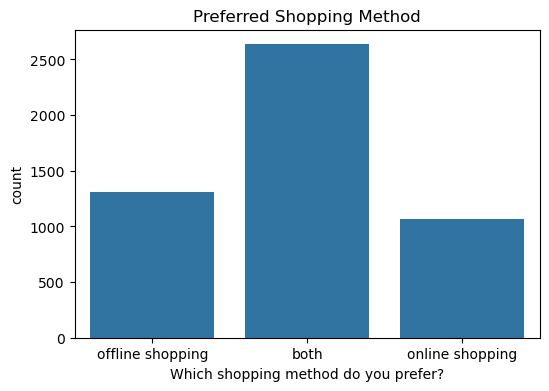

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="Which shopping method do you prefer?", data=df)
plt.title("Preferred Shopping Method")
plt.show()

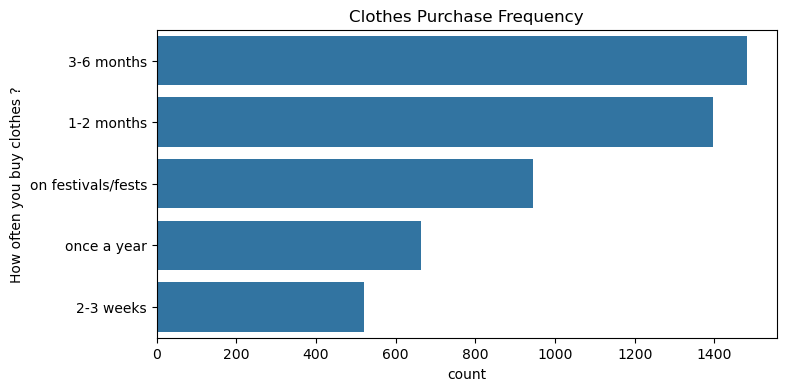

In [16]:
plt.figure(figsize=(8,4))
sns.countplot(
    y="How often you buy clothes ?",
    data=df,
    order=df["How often you buy clothes ?"].value_counts().index
)
plt.title("Clothes Purchase Frequency")
plt.show()

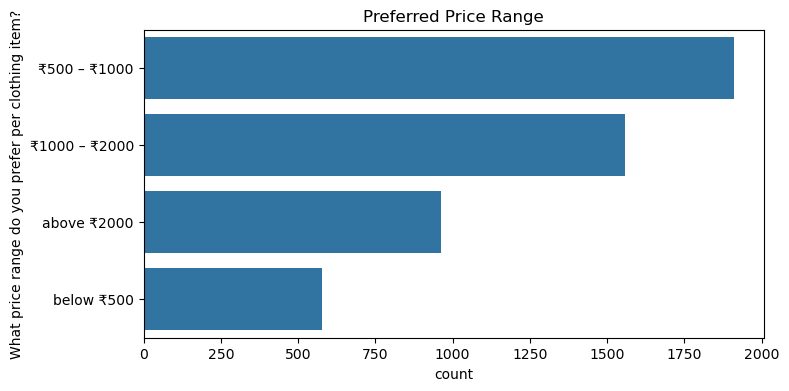

In [17]:
plt.figure(figsize=(8,4))
sns.countplot(
    y="What price range do you prefer per clothing item?",
    data=df,
    order=df["What price range do you prefer per clothing item?"].value_counts().index
)
plt.title("Preferred Price Range")
plt.show()

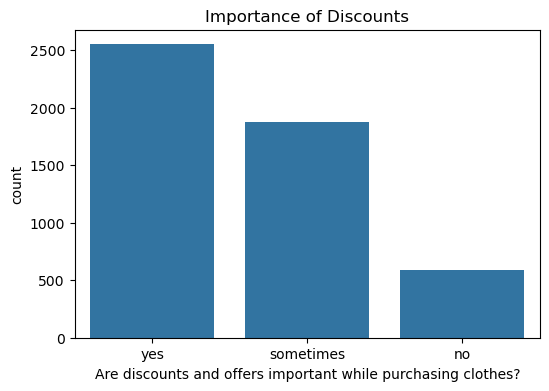

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="Are discounts and offers important while purchasing clothes?",
    data=df
)
plt.title("Importance of Discounts")
plt.show()

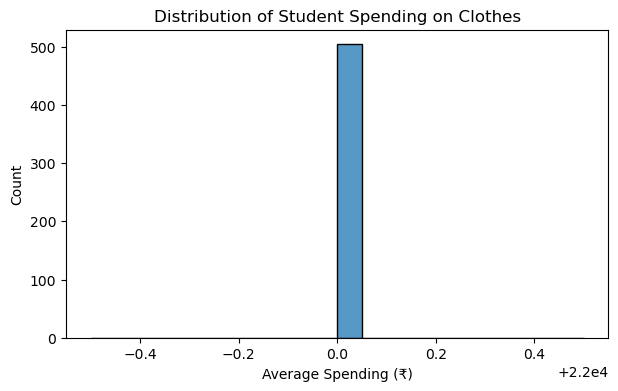

In [25]:
plt.figure(figsize=(7,4))
sns.histplot(df["average_spending"], bins=20)
plt.title("Distribution of Student Spending on Clothes")
plt.xlabel("Average Spending (₹)")
plt.show()

In [36]:
df = df[df["What is your average spending ? (per year)"] < 50000]

In [37]:
df["average_spending"] = df["What is your average spending ? (per year)"]

In [38]:
df["average_spending"].value_counts()

average_spending
20000.0    503
Name: count, dtype: int64

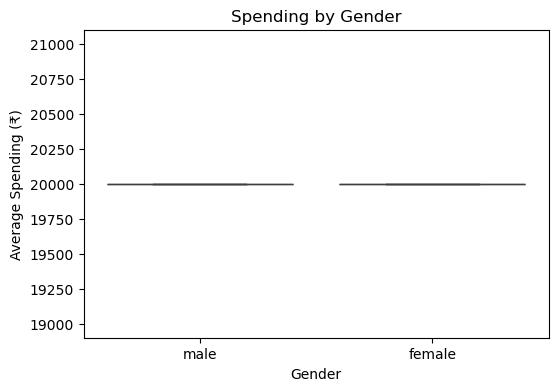

In [41]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Gender", y="average_spending", data=df)

plt.title("Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Spending (₹)")

plt.show()

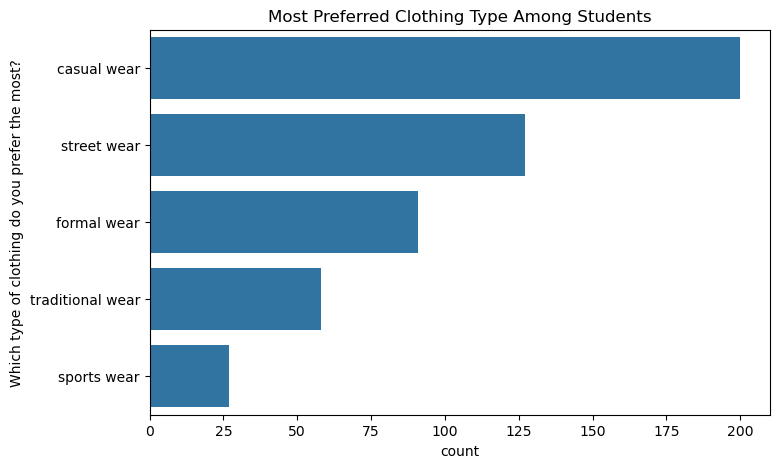

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    y="Which type of clothing do you prefer the most?",
    data=df,
    order=df["Which type of clothing do you prefer the most?"].value_counts().index
)

plt.title("Most Preferred Clothing Type Among Students")

plt.show()

In [44]:
encoded_df = pd.get_dummies(df)
corr = encoded_df.corr()

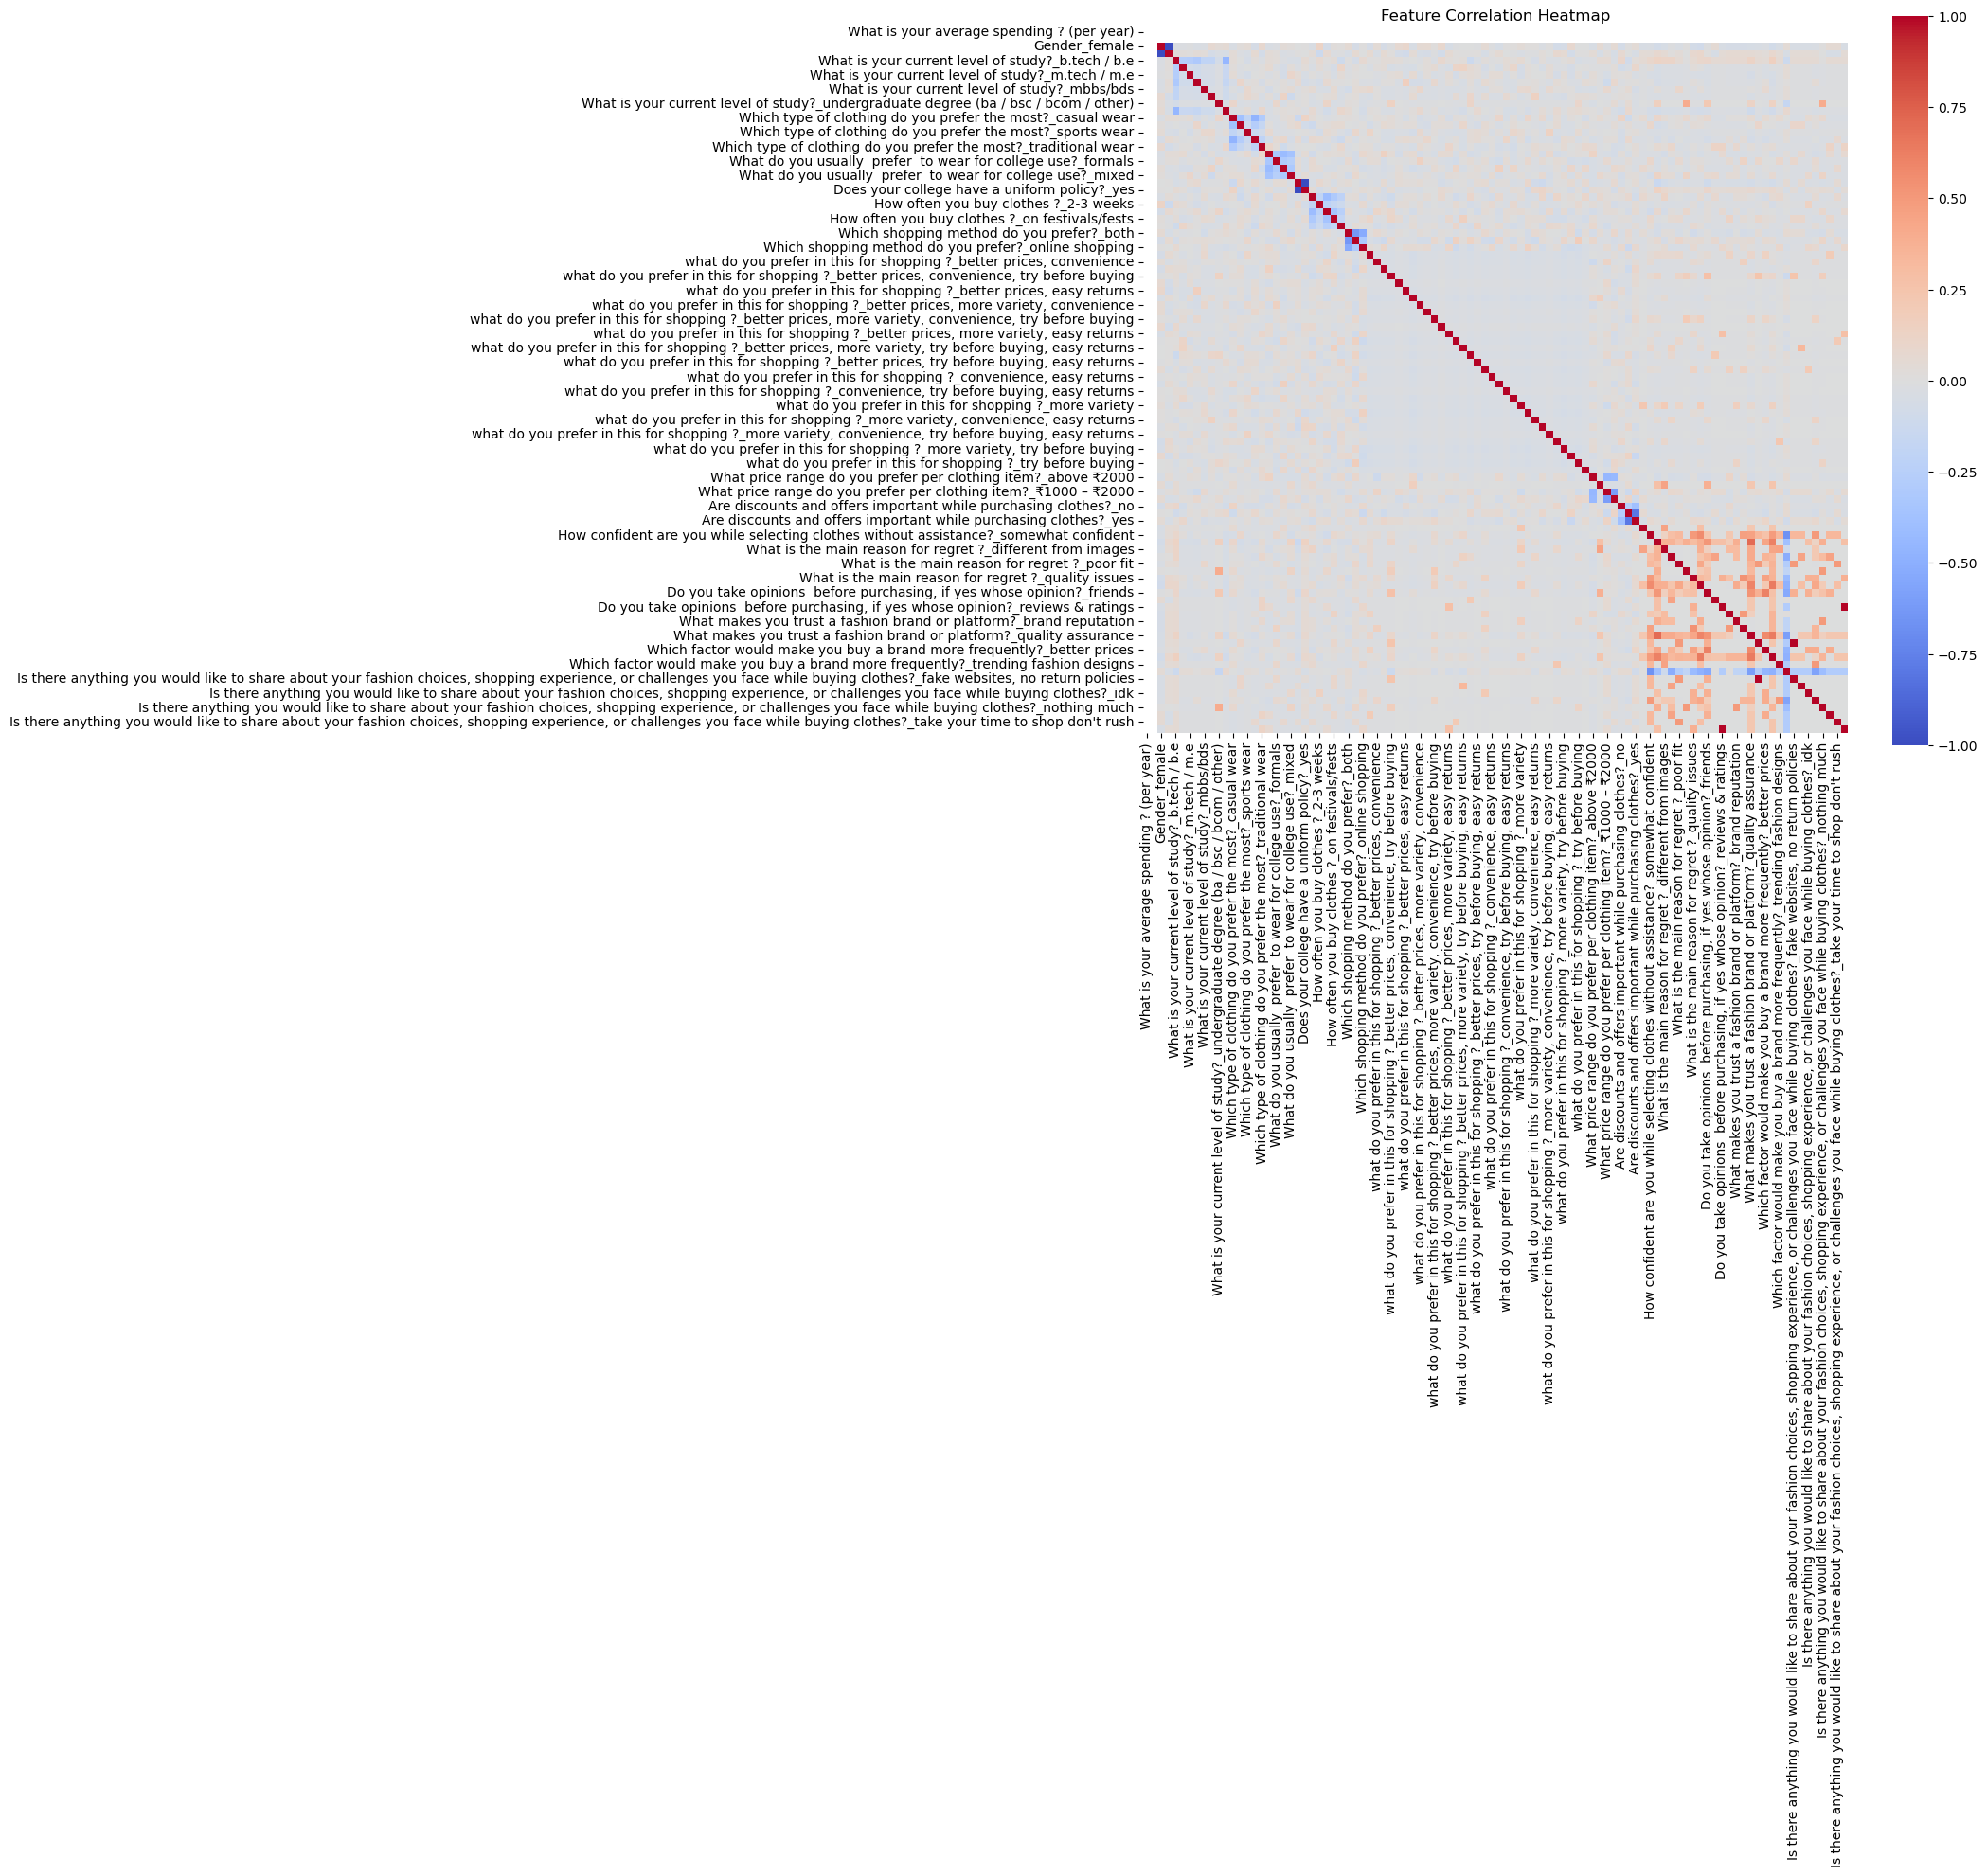

In [49]:
encoded_df = pd.get_dummies(df)

corr = encoded_df.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar=True
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [50]:
gender_dummies = pd.get_dummies(df["Gender"], prefix="gender")
study_dummies = pd.get_dummies(df["What is your current level of study?"], prefix="study")

df_encoded = pd.concat([df, gender_dummies, study_dummies], axis=1)

In [51]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    
    words = text.split()
    
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(words)

df["clean_feedback"] = df["Is there anything you would like to share about your fashion choices, shopping experience, or challenges you face while buying clothes?"].apply(clean_text)

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1,2),
    min_df=1
)

X_text = tfidf.fit_transform(df["clean_feedback"])

In [54]:
words = tfidf.get_feature_names_out()

importance = np.asarray(X_text.sum(axis=0)).ravel()

word_df = pd.DataFrame({
    "word": words,
    "score": importance
})

word_df = word_df.sort_values("score", ascending=False)

word_df.head(20)

,word,score
33,nothing much,1.732051
32,nothing,1.732051
31,much,1.732051
25,idk,1.000000
28,make,0.554700
54,website return,0.377964
53,website,0.377964
34,policy,0.377964
39,return,0.377964
40,return policy,0.377964


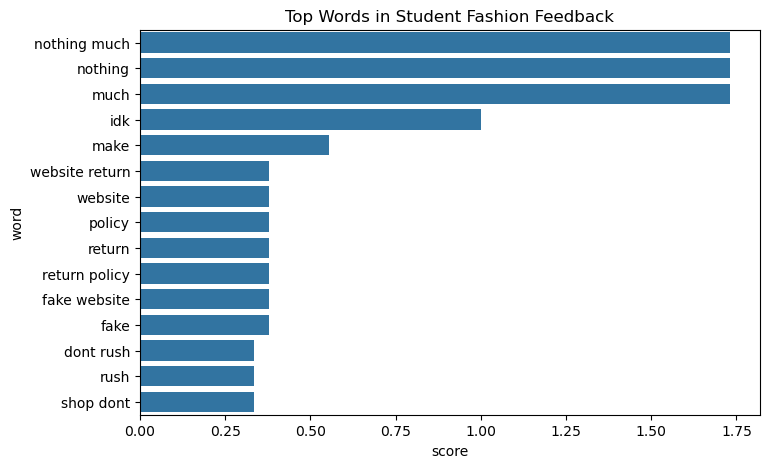

In [55]:
top_words = word_df.head(15)

plt.figure(figsize=(8,5))
sns.barplot(x="score", y="word", data=top_words)
plt.title("Top Words in Student Fashion Feedback")
plt.show()

In [56]:
pd.crosstab(df["Gender"], df["Which shopping method do you prefer?"])

Which shopping method do you prefer?,both,offline shopping,online shopping
Gender,,,
female,127,58,49
male,133,81,55


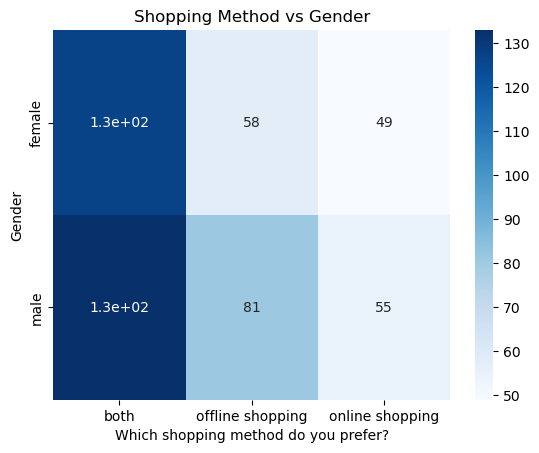

In [57]:
sns.heatmap(
    pd.crosstab(df["Gender"], df["Which shopping method do you prefer?"]),
    annot=True,
    cmap="Blues"
)
plt.title("Shopping Method vs Gender")
plt.show()

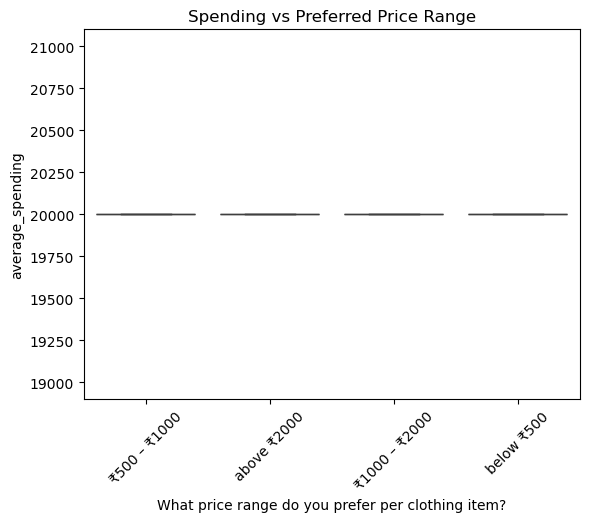

In [58]:
sns.boxplot(
    x="What price range do you prefer per clothing item?",
    y="average_spending",
    data=df
)

plt.xticks(rotation=45)
plt.title("Spending vs Preferred Price Range")
plt.show()

In [59]:
"""Majority of students prefer casual wear.

Online and offline combined shopping is most preferred.

Most students spend ₹5000–₹15000 per year on clothes.

Discounts significantly influence purchasing decisions.

Reviews and brand reputation are major trust factors.

Common challenges include fit issues, quality concerns, and mismatch with online images."""

'Majority of students prefer casual wear.\n\nOnline and offline combined shopping is most preferred.\n\nMost students spend ₹5000–₹15000 per year on clothes.\n\nDiscounts significantly influence purchasing decisions.\n\nReviews and brand reputation are major trust factors.\n\nCommon challenges include fit issues, quality concerns, and mismatch with online images.'

In [60]:
"""The analysis of 5006 student responses reveals that fashion purchasing decisions are influenced by affordability, convenience, and peer influence. Casual clothing dominates student preferences, and students frequently rely on online platforms for variety and pricing benefits. Discounts and brand reputation strongly impact trust and purchase frequency.

Text mining analysis shows that students commonly mention issues related to price, quality, and fit, highlighting areas where fashion retailers can improve customer satisfaction."""

'The analysis of 5006 student responses reveals that fashion purchasing decisions are influenced by affordability, convenience, and peer influence. Casual clothing dominates student preferences, and students frequently rely on online platforms for variety and pricing benefits. Discounts and brand reputation strongly impact trust and purchase frequency.\n\nText mining analysis shows that students commonly mention issues related to price, quality, and fit, highlighting areas where fashion retailers can improve customer satisfaction.'